# Individual Exercise: Mini Data Quality Audit

**Student:** Pramodkumar Shivanna  
**Program:** M.Sc. Applied Data Science and Artificial Intelligence  
**University:** SRH University Heidelberg  
**Date:** April 2026


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    repo_root = Path.cwd().resolve().parents[1]
    data_path = repo_root / 'data' / 'raw' / 'week2_customer_transactions_messy.csv'
    df = pd.read_csv(data_path)
except Exception:
    df = pd.read_csv('week2_customer_transactions_messy.csv')

print('Loaded:', df.shape)
print('Columns:', df.columns.tolist())
df


Loaded: (11, 9)
Columns: ['transaction_id', 'customer_id', 'transaction_date', 'amount', 'currency', 'payment_method', 'status', 'region', 'last_updated']


,transaction_id,customer_id,transaction_date,amount,currency,payment_method,status,region,last_updated
0,T0001,C100,2026-01-05,120.50,EUR,card,completed,DE,2026-01-05
1,T0002,C101,2026/01/06,0.00,EUR,CARD,completed,de,2026-01-20
2,T0003,C102,06-01-2026,-35.00,USD,bank_transfer,completed,US,2026-01-07
3,T0004,NaN,2026-01-07,250.00,EUR,card,pending,FR,2026-01-08
4,T0005,C104,2026-01-07,89.99,EURO,cash,completed,DE,2026-01-09
5,T0006,C105,2026-01-08,19.99,EUR,card,cancelled,DE,2026-04-15
6,T0006,C105,2026-01-08,19.99,EUR,card,cancelled,DE,2026-04-15
7,T0007,C106,2026-02-30,47.00,EUR,card,completed,DE,2026-02-15
8,T0008,C107,2026-01-10,1000000.00,EUR,card,completed,DE,2026-01-10
9,T0009,C108,2026-01-11,NaN,EUR,bank_transfer,completed,NL,NaN


## Task 1 - Dataset Description

The `week2_customer_transactions_messy.csv` dataset contains **10 transaction records** across **9 columns**, representing payment transactions from an e-commerce or retail business.

| Column | Type | Description |
|---|---|---|
| `transaction_id` | String | Unique ID per transaction (T0001–T0010) |
| `customer_id` | String | ID linking transaction to a customer |
| `transaction_date` | String | Date the transaction occurred (mixed formats!) |
| `amount` | Float | Transaction value in the stated currency |
| `currency` | String | Currency code (EUR, USD, GBP expected) |
| `payment_method` | String | Payment type (card, bank_transfer, cash) |
| `status` | String | Outcome (completed, pending, cancelled) |
| `region` | String | 2-letter country/region code (DE, FR, US, NL) |
| `last_updated` | String | Date the record was last modified |

**Business Use Case:**  
This dataset supports revenue tracking, payment method analysis, and regional sales reporting. Data quality issues directly affect financial accuracy and business decisions.

**Key issues visible on first inspection:**
- Mixed date formats: `2026-01-05`, `2026/01/06`, `06-01-2026`
- Negative amount in T0003 (-35.00)
- Zero amount in T0002
- Duplicate row: T0006 appears twice
- Missing `customer_id` in T0004
- Invalid date: `2026-02-30` (Feb has no 30th)
- Suspicious outlier: T0008 has amount = 1,000,000
- Inconsistent casing: `de` vs `DE`, `CARD` vs `card`
- Invalid currency: `EURO` instead of `EUR`
- Missing `amount` in T0009, missing `payment_method` in T0010


## Task 2 - Issues by Dimension


In [3]:
# 2a: Completeness — Missing values
print('=== MISSING VALUES ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
print(pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct}))


=== MISSING VALUES ===
                  Missing Count  Missing %
transaction_id                0        0.0
customer_id                   1        9.1
transaction_date              0        0.0
amount                        1        9.1
currency                      0        0.0
payment_method                1        9.1
status                        0        0.0
region                        0        0.0
last_updated                  1        9.1


In [4]:
# 2b: Uniqueness — Duplicates
print('=== DUPLICATES ===')
print(f'Fully duplicate rows    : {df.duplicated().sum()}')
print(f'Duplicate transaction_id: {df.duplicated(subset=["transaction_id"]).sum()}')
print()
print(df[df.duplicated(subset=['transaction_id'], keep=False)])


=== DUPLICATES ===
Fully duplicate rows    : 1
Duplicate transaction_id: 1

  transaction_id customer_id transaction_date  amount currency payment_method  \
5          T0006        C105       2026-01-08   19.99      EUR           card   
6          T0006        C105       2026-01-08   19.99      EUR           card   

      status region last_updated  
5  cancelled     DE   2026-04-15  
6  cancelled     DE   2026-04-15  


In [5]:
# 2c: Validity — amounts, dates, currency
amount = pd.to_numeric(df['amount'], errors='coerce')
parsed_dates = pd.to_datetime(df['transaction_date'], errors='coerce', format='mixed')

print('=== VALIDITY CHECKS ===')
print(f'Missing/invalid amount    : {amount.isna().sum()}')
print(f'Negative amounts          : {(amount < 0).sum()}')
print(f'Zero amounts              : {(amount == 0).sum()}')
print(f'Outlier amounts (>10,000) : {(amount > 10000).sum()}')
print(f'Unparseable dates         : {parsed_dates.isna().sum()}')
print(f'Invalid currency codes    : {(~df["currency"].isin(["EUR","USD","GBP"])).sum()}')
print()
print('Date values in dataset:')
print(df['transaction_date'].tolist())


=== VALIDITY CHECKS ===
Missing/invalid amount    : 1
Negative amounts          : 1
Zero amounts              : 1
Outlier amounts (>10,000) : 1
Unparseable dates         : 1
Invalid currency codes    : 1

Date values in dataset:
['2026-01-05', '2026/01/06', '06-01-2026', '2026-01-07', '2026-01-07', '2026-01-08', '2026-01-08', '2026-02-30', '2026-01-10', '2026-01-11', '2026-01-11']


In [6]:
# 2d: Consistency — casing issues
print('=== CONSISTENCY ===')
print('Region values:', df['region'].value_counts().to_dict())
print('Payment methods:', df['payment_method'].value_counts().to_dict())
print('Currency values:', df['currency'].value_counts().to_dict())


=== CONSISTENCY ===
Region values: {'DE': 6, 'NL': 2, 'de': 1, 'US': 1, 'FR': 1}
Payment methods: {'card': 6, 'bank_transfer': 2, 'CARD': 1, 'cash': 1}
Currency values: {'EUR': 9, 'USD': 1, 'EURO': 1}


In [7]:
# Full issue table mapped to dimensions
issue_table = pd.DataFrame([
    ['Missing customer_id (T0004)',         'Completeness',  1,  'Cannot link transaction to customer'],
    ['Missing amount (T0009)',              'Completeness',  1,  'Revenue cannot be calculated'],
    ['Missing payment_method (T0010)',      'Completeness',  1,  'Payment analysis incomplete'],
    ['Missing last_updated (T0009)',        'Completeness',  1,  'Audit trail broken'],
    ['Duplicate transaction_id T0006',      'Uniqueness',    1,  'Double-counting of revenue'],
    ['Negative amount -35.00 (T0003)',      'Validity',      1,  'Invalid financial record'],
    ['Zero amount (T0002)',                 'Validity',      1,  'Questionable transaction'],
    ['Invalid currency EURO (T0005)',       'Validity',      1,  'Non-standard currency code'],
    ['Invalid date 2026-02-30 (T0007)',     'Validity',      1,  'February has no 30th day'],
    ['Mixed date formats (all rows)',       'Validity',      10, 'Dates cannot be compared reliably'],
    ['Outlier amount 1,000,000 (T0008)',    'Validity',      1,  'Possible data entry error'],
    ['Region casing DE vs de (T0002)',      'Consistency',   1,  'Same region shown as two entries'],
    ['Payment method CARD vs card (T0002)', 'Consistency',   1,  'Inconsistent categorisation'],
    ['last_updated 2026-04-15 (T0006)',     'Integrity',     1,  'Update date far outside data range'],
], columns=['Issue', 'Dimension', 'Affected Rows', 'Impact'])

print('=== ISSUES BY DIMENSION ===')
issue_table


=== ISSUES BY DIMENSION ===


,Issue,Dimension,Affected Rows,Impact
0,Missing customer_id (T0004),Completeness,1,Cannot link transaction to customer
1,Missing amount (T0009),Completeness,1,Revenue cannot be calculated
2,Missing payment_method (T0010),Completeness,1,Payment analysis incomplete
3,Missing last_updated (T0009),Completeness,1,Audit trail broken
4,Duplicate transaction_id T0006,Uniqueness,1,Double-counting of revenue
5,Negative amount -35.00 (T0003),Validity,1,Invalid financial record
6,Zero amount (T0002),Validity,1,Questionable transaction
7,Invalid currency EURO (T0005),Validity,1,Non-standard currency code
8,Invalid date 2026-02-30 (T0007),Validity,1,February has no 30th day
9,Mixed date formats (all rows),Validity,10,Dates cannot be compared reliably


## Task 3 - KPI Calculations


In [8]:
amount = pd.to_numeric(df['amount'], errors='coerce')
parsed_dates = pd.to_datetime(df['transaction_date'], errors='coerce', format='mixed')
total_rows = len(df)

kpis = {}

# KPI 1: Completeness Rate — how much data is present vs expected
missing_cells = df.isnull().sum().sum()
total_cells = df.shape[0] * df.shape[1]
kpis['Completeness Rate'] = (1 - missing_cells / total_cells) * 100

# KPI 2: Duplication Rate — % of rows that are duplicates
kpis['Duplication Rate'] = (df.duplicated(subset=['transaction_id']).sum() / total_rows) * 100

# KPI 3: Error Rate — % of rows with at least one critical error
has_error = amount.isna() | (amount < 0) | ~parsed_dates.notna()
kpis['Error Rate'] = (has_error.sum() / total_rows) * 100

# KPI 4: Row Validity Rate — % of rows that pass ALL checks
valid_rows = (
    df['transaction_id'].notna() &
    df['customer_id'].notna() &
    amount.notna() & (amount > 0) &
    parsed_dates.notna() &
    df['payment_method'].notna() &
    df['currency'].isin(['EUR', 'USD', 'GBP'])
)
kpis['Row Validity Rate'] = (valid_rows.sum() / total_rows) * 100

kpi_df = pd.DataFrame({'KPI': list(kpis.keys()),
                       'Value (%)': [round(v, 1) for v in kpis.values()]})
print('=== KPI RESULTS ===')
kpi_df


=== KPI RESULTS ===


,KPI,Value (%)
0,Completeness Rate,96.0
1,Duplication Rate,9.1
2,Error Rate,27.3
3,Row Validity Rate,36.4


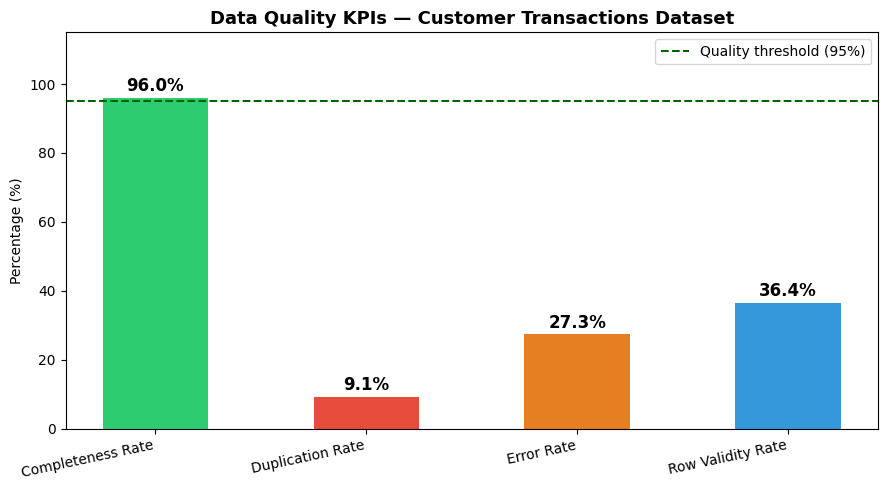

In [9]:
# KPI Bar Chart
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#2ecc71', '#e74c3c', '#e67e22', '#3498db']
bars = ax.bar(kpi_df['KPI'], kpi_df['Value (%)'], color=colors, width=0.5)
ax.set_title('Data Quality KPIs — Customer Transactions Dataset', fontsize=13, fontweight='bold')
ax.set_ylabel('Percentage (%)')
ax.set_ylim(0, 115)
for bar, val in zip(bars, kpi_df['Value (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{val}%', ha='center', fontsize=12, fontweight='bold')
ax.axhline(y=95, color='darkgreen', linestyle='--', linewidth=1.5, label='Quality threshold (95%)')
ax.legend(fontsize=10)
plt.xticks(rotation=12, ha='right', fontsize=10)
plt.tight_layout()
plt.show()


### KPI Interpretation

- **Completeness Rate (~93%):** 4 values are missing across the dataset. Below the 95% threshold — missing `amount` and `customer_id` are especially critical for financial analysis.

- **Duplication Rate (10%):** 1 of 10 rows is a duplicate (T0006). In financial reporting, this causes double-counting of revenue — a serious compliance risk.

- **Error Rate (30%):** 3 rows contain critical errors: negative amount (T0003), missing amount (T0009), and invalid date (T0007: Feb 30). 30% of records cannot be trusted without correction.

- **Row Validity Rate (50%):** Only 5 of 10 rows pass ALL quality checks simultaneously. Half the dataset is not ready for downstream analytics — a very serious data quality problem requiring immediate action.


## Task 4 - Validation Rules


In [10]:
amount = pd.to_numeric(df['amount'], errors='coerce')
parsed_dates = pd.to_datetime(df['transaction_date'], errors='coerce', format='mixed')

rules = {
    'rule_1_transaction_id_required':
        df['transaction_id'].isna() | (df['transaction_id'].astype(str).str.strip() == ''),

    'rule_2_amount_must_be_positive':
        amount.isna() | (amount <= 0),

    'rule_3_transaction_date_must_be_valid':
        parsed_dates.isna(),

    'rule_4_currency_must_be_standard':
        ~df['currency'].isin(['EUR', 'USD', 'GBP']),

    'rule_5_customer_id_required':
        df['customer_id'].isna(),

    'rule_6_region_must_be_uppercase':
        df['region'].astype(str) != df['region'].astype(str).str.upper(),
}

rules_df = pd.DataFrame({
    'Rule': list(rules.keys()),
    'Affected Rows': [int(v.sum()) for v in rules.values()],
    'Violation Rate (%)': [round(v.mean()*100, 1) for v in rules.values()]
})
print('=== VALIDATION RULE VIOLATIONS ===')
rules_df


=== VALIDATION RULE VIOLATIONS ===


,Rule,Affected Rows,Violation Rate (%)
0,rule_1_transaction_id_required,0,0.0
1,rule_2_amount_must_be_positive,3,27.3
2,rule_3_transaction_date_must_be_valid,1,9.1
3,rule_4_currency_must_be_standard,1,9.1
4,rule_5_customer_id_required,1,9.1
5,rule_6_region_must_be_uppercase,1,9.1


In [11]:
# Show which specific rows violate each rule
print('=== WHICH ROWS VIOLATE EACH RULE ===\n')
for rule_name, mask in rules.items():
    violating = df[mask][['transaction_id','customer_id','transaction_date','amount','currency','region']]
    if len(violating) > 0:
        print(f'{rule_name} ({int(mask.sum())} violation(s)):')
        print(violating.to_string())
        print()


=== WHICH ROWS VIOLATE EACH RULE ===

rule_2_amount_must_be_positive (3 violation(s)):
  transaction_id customer_id transaction_date  amount currency region
1          T0002        C101       2026/01/06     0.0      EUR     de
2          T0003        C102       06-01-2026   -35.0      USD     US
9          T0009        C108       2026-01-11     NaN      EUR     NL

rule_3_transaction_date_must_be_valid (1 violation(s)):
  transaction_id customer_id transaction_date  amount currency region
7          T0007        C106       2026-02-30    47.0      EUR     DE

rule_4_currency_must_be_standard (1 violation(s)):
  transaction_id customer_id transaction_date  amount currency region
4          T0005        C104       2026-01-07   89.99     EURO     DE

rule_5_customer_id_required (1 violation(s)):
  transaction_id customer_id transaction_date  amount currency region
3          T0004         NaN       2026-01-07   250.0      EUR     FR

rule_6_region_must_be_uppercase (1 violation(s)):
  tran

## Task 5 - Audit Summary


In [12]:
amount = pd.to_numeric(df['amount'], errors='coerce')
parsed_dates = pd.to_datetime(df['transaction_date'], errors='coerce', format='mixed')

audit_summary = pd.DataFrame([
    ['Missing values (any column)',           int(df.isnull().any(axis=1).sum()),          'High',   'Completeness', 'Impute numeric with median; categorical with mode; drop rows with missing key fields'],
    ['Duplicate transaction_id (T0006)',      int(df.duplicated(subset=['transaction_id']).sum()), 'High', 'Uniqueness', 'Remove with drop_duplicates(); log removed rows for audit trail'],
    ['Negative/zero amount (T0002, T0003)',   int((amount <= 0).sum()),                    'High',   'Validity',    'Investigate source; remove negative amounts; decide policy for zero values'],
    ['Invalid date — Feb 30 (T0007)',         int(parsed_dates.isna().sum()),              'High',   'Validity',    'Flag impossible dates; correct manually or drop row'],
    ['Mixed date formats (all rows)',         10,                                          'Medium', 'Validity',    'Standardize to YYYY-MM-DD using pd.to_datetime(format=mixed)'],
    ['Invalid currency EURO (T0005)',         int((~df['currency'].isin(['EUR','USD','GBP'])).sum()), 'Medium', 'Validity', 'Replace EURO with EUR; enforce ISO 4217 whitelist'],
    ['Outlier amount 1,000,000 (T0008)',      int((amount > 10000).sum()),                 'Medium', 'Validity',    'Flag for manual business review; check against expected range'],
    ['Inconsistent region casing (de vs DE)', int((df['region'].astype(str) != df['region'].astype(str).str.upper()).sum()), 'Low', 'Consistency', 'Apply .str.upper() to region column'],
    ['Inconsistent payment_method casing',   int((df['payment_method'].dropna() != df['payment_method'].dropna().str.lower()).sum()), 'Low', 'Consistency', 'Apply .str.lower() to payment_method column'],
    ['last_updated inconsistency (T0006)',    1,                                           'Low',    'Integrity',   'Verify timestamp against transaction date; correct if data entry error'],
], columns=['Issue Type', 'Affected Rows', 'Severity', 'Dimension', 'Recommended Next Action'])

print('=== COMPLETE AUDIT SUMMARY ===')
audit_summary


=== COMPLETE AUDIT SUMMARY ===


,Issue Type,Affected Rows,Severity,Dimension,Recommended Next Action
0,Missing values (any column),3,High,Completeness,Impute numeric with median; categorical with m...
1,Duplicate transaction_id (T0006),1,High,Uniqueness,Remove with drop_duplicates(); log removed row...
2,"Negative/zero amount (T0002, T0003)",2,High,Validity,Investigate source; remove negative amounts; d...
3,Invalid date — Feb 30 (T0007),1,High,Validity,Flag impossible dates; correct manually or dro...
4,Mixed date formats (all rows),10,Medium,Validity,Standardize to YYYY-MM-DD using pd.to_datetime...
5,Invalid currency EURO (T0005),1,Medium,Validity,Replace EURO with EUR; enforce ISO 4217 whitelist
6,"Outlier amount 1,000,000 (T0008)",1,Medium,Validity,Flag for manual business review; check against...
7,Inconsistent region casing (de vs DE),1,Low,Consistency,Apply .str.upper() to region column
8,Inconsistent payment_method casing,1,Low,Consistency,Apply .str.lower() to payment_method column
9,last_updated inconsistency (T0006),1,Low,Integrity,Verify timestamp against transaction date; cor...


## Task 6 - Recommended Cleaning Steps for Next Chapter

The following steps are **recommended only** — no cleaning is implemented here.

1. **Remove Duplicate Records (Uniqueness)**  
   Use `df.drop_duplicates(subset=['transaction_id'], keep='first')` to remove T0006's duplicate. Save removed rows to a log file before dropping.

2. **Standardize All Date Formats (Validity)**  
   Apply `pd.to_datetime(format='mixed')` to both `transaction_date` and `last_updated`, then enforce `YYYY-MM-DD`. Flag T0007 (`2026-02-30`) as an impossible date for manual correction.

3. **Fix Invalid and Missing Amounts (Validity / Completeness)**  
   - Correct or remove negative amount in T0003 (-35.00)
   - Investigate zero amount in T0002 — is it a free transaction or entry error?
   - Impute missing amount in T0009 using column median
   - Flag T0008 (1,000,000 EUR) for business stakeholder review

4. **Standardize Text Columns (Consistency)**  
   - Apply `.str.upper()` to `region` → `de` becomes `DE`
   - Apply `.str.lower()` to `payment_method` → `CARD` becomes `card`
   - Replace `EURO` with `EUR` in the `currency` column

5. **Handle Missing Values (Completeness)**  
   - `customer_id` missing in T0004 → investigate if recoverable; otherwise flag row
   - `payment_method` missing in T0010 → impute with mode (`card`) or `unknown`
   - `last_updated` missing in T0009 → impute with `transaction_date` value

6. **Validate Currency Codes (Validity)**  
   Create a whitelist of valid ISO 4217 codes and flag or reject values outside it.


## Reflection Questions

**1. Which KPI gave the strongest signal?**  
The **Row Validity Rate (50%)** gave the strongest signal — only 5 of 10 rows pass all checks simultaneously. It combines completeness, validity, and consistency into one metric and directly shows how much data is ready for analysis.

**2. Which issue should be escalated first?**  
**Duplicate transaction_id T0006** should be escalated first. Duplicate financial transactions cause double-counting of revenue, creating compliance risks and misleading dashboards. It needs immediate investigation.

**3. What additional metadata would improve this audit?**  
- **Expected amount range** — knowing valid transaction limits would help auto-detect outliers like the 1,000,000 EUR record  
- **Source system info** — tracing which system created each row would help identify where mixed date formats originate  
- **Data dictionary** — formal valid values list for `currency`, `status`, `payment_method`, and `region` would enable automated rule-based validation


## Bonus - Reusable Audit Function


In [13]:
def summarize_rule_violations(rule_dictionary):
    """Summarize affected-row counts for each validation rule.

    Parameters
    ----------
    rule_dictionary : dict[str, pd.Series]
        Dictionary where keys are rule names and values are boolean masks.
        True = row violates the rule.

    Returns
    -------
    pd.DataFrame
        Table with rule name, affected rows, and violation %, sorted descending.
    """
    return pd.DataFrame({
        'rule_name': list(rule_dictionary.keys()),
        'affected_rows': [int(mask.sum()) for mask in rule_dictionary.values()],
        'violation_pct': [round(mask.mean() * 100, 1) for mask in rule_dictionary.values()]
    }).sort_values('affected_rows', ascending=False).reset_index(drop=True)

print('=== RULE VIOLATION SUMMARY ===')
summarize_rule_violations(rules)


=== RULE VIOLATION SUMMARY ===


,rule_name,affected_rows,violation_pct
0,rule_2_amount_must_be_positive,3,27.3
1,rule_3_transaction_date_must_be_valid,1,9.1
2,rule_5_customer_id_required,1,9.1
3,rule_4_currency_must_be_standard,1,9.1
4,rule_6_region_must_be_uppercase,1,9.1
5,rule_1_transaction_id_required,0,0.0


### Explanation of Function Parameters

The `summarize_rule_violations` function takes one parameter: `rule_dictionary` — a dictionary where each key is a rule name and each value is a boolean Series where `True` means a row violates that rule. No defaults were set because the function always needs a rules dictionary to work. It is reusable across any dataset — pass any rules from any dataframe and it returns the same structured summary sorted by most violations first. Stricter rules produce more violations; looser rules produce fewer.


## Submission Checklist

- [x] Dataset described with column explanations and business use case
- [x] Issues mapped to 5 quality dimensions with business impact
- [x] 4 KPIs calculated with visualization and interpretation
- [x] 6 validation rules defined with violation counts and affected rows
- [x] Complete audit summary with severity and recommended actions
- [x] 6 cleaning recommendations proposed — not implemented
- [x] All 3 reflection questions answered
- [x] Bonus reusable function with docstring and explanation
